# ロジスティック回帰

ベルヌーイ分布に従う変数の統計的回帰モデルの一種．主に二値分類で使われる．

この資料では，ロジスティック回帰をスクラッチ実装し，理解することを目標とする．

なお，前提として線形回帰の知識があるとする．

※ ただいま後半の実装以降が全然まとまっていないので閲覧する際は注意してください．

---
## 本家の出力の確認

scikit-learnでの出力

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import ArtistAnimation
import time
import random
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim

sklearnのmake_classificationメソッドでデータを用意する．

なお．データの数は上げすぎない方が良い．\
ここでスクラッチ実装するモデルでは，データ数が多すぎると，計算量が多すぎて学習が収束しない．
その理由は後々

参考
- https://plantprogramer.com/data_generator/

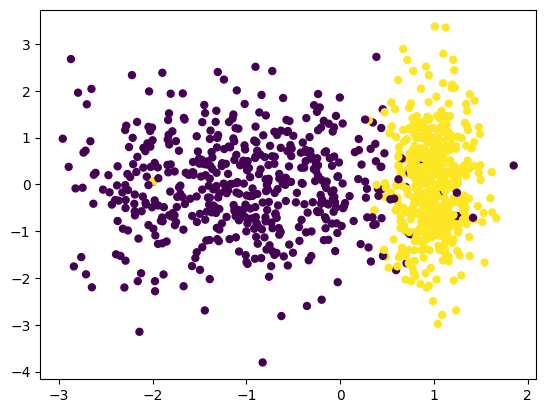

In [2]:
N = 1000  # データの数
d = 2  # 次元数
K = 2  # クラス数

X, y = make_classification(
    n_samples=N,
    n_features=d,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=K,
    random_state=20,
)

plt.scatter(X[:, 0], X[:, 1], marker="o", c=y, s=25)
plt.show()

skleanでは，どのようなハイパーパラメータがあるのかをみてみる．

興味のない人は飛ばそう．

In [3]:
model = LogisticRegression(
    penalty=None,  # 正則化．(L1, L2, elasticnet)
    dual=False,
    tol=0.0001,  # 誤差の許容値
    C=1.0,  # 正則化の強さ
    fit_intercept=False,  # バイアス項を入れるかどうか，データの質によって変える．
    intercept_scaling=1.0,  # solver='liblinear'でfit_intercept=Trueのときに発動
    class_weight=None,  # クラスの数に応じて重みを受けることができる．
    random_state=None,  # solver=['sag','saga','liblinear']のときにデータをシャッフルする．
    solver="newton-cg",  # 最適化関数．newton-cgは，共役勾配法を導入したニュートン法のこと．
    max_iter=100,  # 最大更新回数．(newton系の最適化関数は収束が早いため，更新回数は少ない．)
    multi_class="auto",
    verbose=0,
    warm_start=False,  # 前のソリューションの値をそのまま持ってくる，でない場合はただ初期化するだけ
    n_jobs=None,  # 使用するcpuのコア数
    l1_ratio=None,  # elasticnetのときの正則化割合，l1の割合を操作できる．
)

モデルを学習させる．どのくらい学習に時間がかかるのか．などをみてみよう．

In [4]:
start = time.time()
model.fit(X, y)
end = time.time()
time_diff = end - start
print("学習にかかった時間", time_diff)
print("クラス数", model.classes_)
print("特徴量の数", model.n_features_in_)
print("coef", model.coef_.flatten())
print("intercept", model.intercept_)
print("反復数", model.n_iter_)

学習にかかった時間 0.019304990768432617
クラス数 [0 1]
特徴量の数 2
coef [3.62605703 0.07726773]
intercept [0.]
反復数 [5]


/Users/takahashikaisei/mydir/local-repository/machine-learning/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


一応予測値も出してみる．

In [5]:
pred = model.predict(X)
print(accuracy_score(y, pred))

0.942


### scratch実装

In [6]:
class SLogisticRegression:
    def __init__(self, tol: float = 0.0001, max_iter: int = 100):
        self.tol = tol
        self.max_iter = max_iter

    @staticmethod
    def _sigmoid(Xw):
        return 1 / (1 + np.exp(-Xw))

    def fit(self, x, y):
        self.w = np.random.randn(x.shape[1])
        # self.R = np.identity(x.shape[0])
        tol_vec = np.full(x.shape[1], self.tol)
        diff = np.full(x.shape[1], np.inf)
        tol_ = 0
        while np.any(diff > tol_vec) and (tol_ < self.max_iter):
            y_hat = self._sigmoid(x @ self.w)
            R = np.diag(y_hat * (1 - y_hat))
            w_new = self.w - (
                np.linalg.pinv((x.T @ R) @ x) @ x.T @ (y_hat - y)
            )
            diff = w_new - self.w
            tol_ += 1
            self.w = w_new

    def predict(self, x):
        y_hat_Xw = np.dot(x, self.w)
        y_pred = self._sigmoid(y_hat_Xw)
        for _ in range(x.shape[0]):
            if y_pred[_] > 0.5:
                y_pred[_] = 1
            elif y_pred[_] < 0.5:
                y_pred[_] = 0
        return y_pred

In [75]:
Smodel = SLogisticRegression(tol=0.0001, max_iter=100)

start = time.time()
Smodel.fit(X, y)
end = time.time()
time_diff = end - start
print("実行時間", time_diff)

print("coef_", Smodel.w)
pred = Smodel.predict(X)
print("accuracy", accuracy_score(y, pred))

実行時間 0.03849077224731445
coef_ [3.62964534 0.07741521]
accuracy 0.942


### torchで実装

In [78]:
X_tensor = torch.from_numpy(X.astype(np.float32))
X_tensor.size()
y_tensor = torch.from_numpy(y.astype(np.float32))
y_tensor.size()

torch.Size([1000])

torch実装: tensor([3.1298, 0.0575])
scratch実装: [3.62964534 0.07741521]
accuracy 0.942


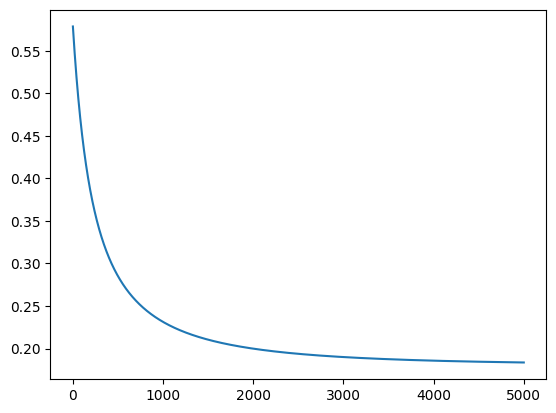

In [256]:
class TLogisticRegression(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc = nn.Linear(input_size, 1, bias=False)

    def forward(self, x):
        x = self.fc(x)
        return F.sigmoid(x)


model = TLogisticRegression(2)
output = model(X_tensor)
output.size()

optimizer = optim.SGD(model.parameters(), lr=0.01)
loss_func = nn.BCELoss()

all_loss = []
for epoch in range(5000):
    loss = 0
    optimizer.zero_grad()
    output = model(X_tensor).flatten()
    loss = loss_func(output, y_tensor)
    all_loss.append(loss.item())
    loss.backward()
    optimizer.step()

fc_weight = model.state_dict()["fc.weight"][0]
print(f"torch実装: {fc_weight}")
print(f"scratch実装: {Smodel.w}")

pred_list = []
pred = model.forward(X_tensor).flatten()
pred_list.extend((pred >= 0.5).float().numpy())
print("accuracy", accuracy_score(y, pred_list))

plt.plot(range(len(all_loss)), all_loss)
plt.show()

学習開始...
Epoch [100/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [200/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [300/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [400/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [500/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [600/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [700/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [800/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [900/1000], Loss: 0.1808, Accuracy: 0.9420
Epoch [1000/1000], Loss: 0.1808, Accuracy: 0.9420
学習時間: 0.109秒

モデル比較:
torch実装:   [3.6296444  0.07741517]
scratch実装: [3.62964534 0.07741521]

PyTorch実装 accuracy: 0.9420


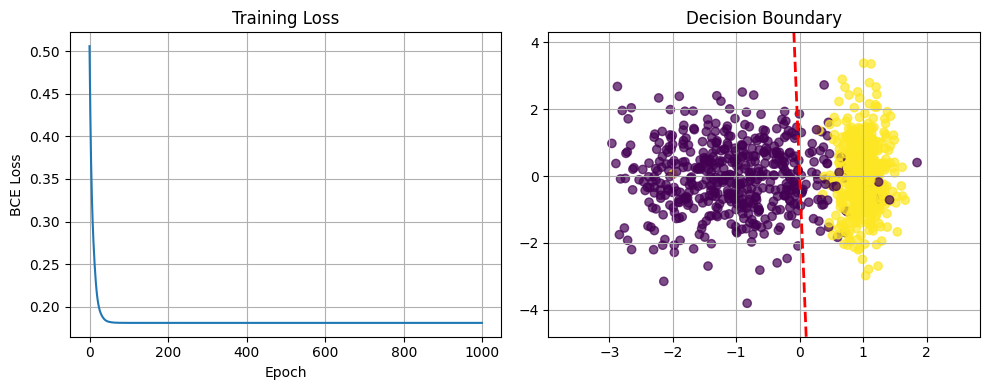

In [258]:
class TLogisticRegression(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc = nn.Linear(input_size, 1, bias=False)

    def forward(self, x):
        return torch.sigmoid(self.fc(x))

    def predict(self, x):
        """予測メソッドを追加"""
        with torch.no_grad():
            probs = self.forward(x)
            return (probs >= 0.5).float()


# データ準備の改善
X_tensor = torch.from_numpy(X.astype(np.float32))
y_tensor = torch.from_numpy(y.astype(np.float32)).view(-1, 1)  # 形状を合わせる

# モデルの初期化
torch.manual_seed(42)  # 再現性のため
model = TLogisticRegression(2)

# オプティマイザと損失関数
optimizer = optim.Adam(model.parameters(), lr=0.1)  # Adamに変更、学習率上げる
loss_func = nn.BCELoss()

# 学習の改善版
epochs = 1000  # エポック数を減らす
all_loss = []
print_interval = 100

print("学習開始...")
start_time = time.time()

for epoch in range(epochs):
    # Forward pass
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = loss_func(output, y_tensor)

    # Backward pass
    loss.backward()
    optimizer.step()

    # 損失を記録
    all_loss.append(loss.item())

    # 進捗表示
    if (epoch + 1) % print_interval == 0:
        with torch.no_grad():
            pred = model.predict(X_tensor)
            acc = accuracy_score(y_tensor.numpy(), pred.numpy())
            print(
                f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Accuracy: {acc:.4f}"
            )

end_time = time.time()
print(f"学習時間: {end_time - start_time:.3f}秒")

# 結果の比較
fc_weight = model.state_dict()["fc.weight"][0].numpy()
print(f"\nモデル比較:")
print(f"torch実装:   {fc_weight}")
print(f"scratch実装: {Smodel.w}")

# 最終的な予測精度
with torch.no_grad():
    torch_pred = model.predict(X_tensor).numpy().flatten()
    torch_acc = accuracy_score(y, torch_pred)
    print(f"\nPyTorch実装 accuracy: {torch_acc:.4f}")

# 損失の可視化
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(all_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(True)

# 決定境界の可視化
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", alpha=0.7)
plt.title("Decision Boundary")

# 決定境界を描画
if fc_weight.shape[0] == 2:  # 2次元の場合のみ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1)
    )

    with torch.no_grad():
        grid_tensor = torch.from_numpy(
            np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
        )
        Z = model(grid_tensor).numpy().reshape(xx.shape)

    plt.contour(
        xx, yy, Z, levels=[0.5], colors="red", linestyles="--", linewidths=2
    )

plt.grid(True)
plt.tight_layout()
plt.show()